# Cleaning a Lightcurve Using TESS-GAIA Light Curve (TGLC)
## Author
Aidan Niklaus

## Citations
[TeHanHunter](https://github.com/TeHanHunter/TESS_Gaia_Light_Curve/blob/main/tutorial/TGLC_tutorial.ipynb)

## Learning Goals
- Become familiar with Lightkurve basics
- Become familiar with TGLC basics
- Handle common TGLC errors
- Become familiar with quality flags
- Gain a basic understanding of PSF photometry vs. aperture photometry
- Open and work with FITS files
- Understand when/why to use TGLC
- Create a clean lightcurve using TGLC

## Keywords
Lightcurve, TESS, GAIA, TGLC, PSF photometry, FITS files, quality flags

## Summary
This tutorial will demonstrate how to utilize the Python packages TGLC and Lightkurve create a clean lightcurve of a dim/crowded star.

## Imports
Note: if this is your first time using TGLC, you first must pip install it.

In [1]:
# I have already done this, so will comment it out to reduce the length of this tutorial

# # '%' symbol allows for pip install to work in Jupyter Notebook cell (normally pip install works in the terminal)
# # '--upgrade' automatically installs updates
# %pip install tglc --upgrade

In [2]:
import lightkurve as lk
from lightkurve import LightCurve
import matplotlib.pyplot as plt
import os
from astropy.io import fits
import tglc
from tglc.quick_lc import tglc_lc

# Makes plots appear directly after respective code block; functionally the same as "plt.show()"
%matplotlib inline

This tutorial uses TGLC version 0.7.0. In order to obtain this version, you must have a version of Python between 3.8.0 and 3.13.0 (not including 3.13.0). You can check your version with the code blocks below.

In [4]:
tglc.__version__

'0.7.0'

In [5]:
import platform
platform.python_version()

'3.12.13'

## Step 1: Initialization
Whether you're coming from [quality bitmasking](https://github.com/aidanniklaus/Summer-Research-2026/blob/main/Tutorials/Quality_Bitmasking_LC_Decision_Tree_Tutorial.ipynb) or straight from [making a lightcurve from an FFI](https://github.com/aidanniklaus/Summer-Research-2026/blob/main/Tutorials/FFI_LC_Decision_Tree_Tutorial.ipynb), in the previous tutorial the example lightcurve didn't need any more cleaning; but what if yours does? This is most likely a result of working with a particularly faint and/or crowded star, meaning the astrophysical signal cannot shine through contamination even after denoising the graph using background masking and quality bitmasking. Luckily for us, TESS-GAIA Light Curve (TGLC) is specifically structured to handle those extra faint/crowded stars! For this example, let's use Sector 54 of the star TIC 284294975, which has a "sawtooth" noise pattern post-background masking and quality bitmasking:

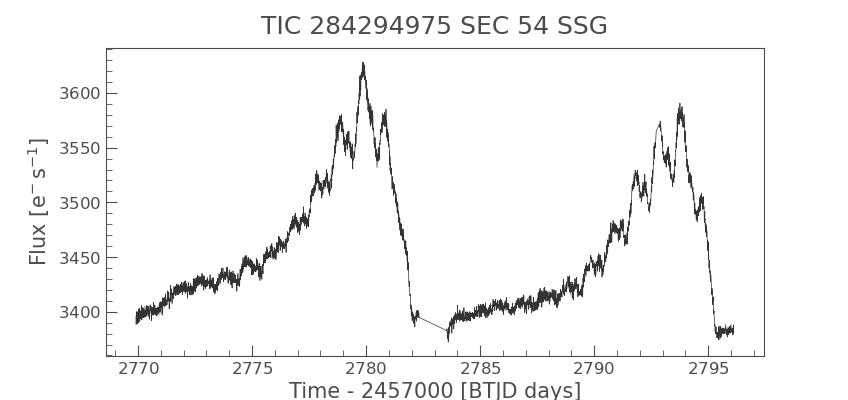

To initialize TGLC for our particular lightcurve, we need to give it our target star and the sector it was observed from. Additionally, TGLC needs a location to save the various files it creates, saves, and uses throughout its process. By default, it will save them all to the current directory, but for organizational purposes let's make a new folder within this directory that is specific to our lightcurve.

In [4]:
# Defining our target star and sector for later
target = 'TIC 284294975'
sector = 54

# Specifically naming the directory we want TGLC to save/access files to/from
local_directory = f'{target} SEC {sector} TGLC/'

# Creating that new directory (if it doesn't already exist) within our current directory
os.makedirs(local_directory, exist_ok=True)

## Step 2: Running TGLC
Now that we have initialized those variables, we can plug them into TGLC and have it create the files for our new lightcurve. Note: this is a very computational taxing process so it may take a while. Furthermore, connection errors, MAST unavailibility, timeout errors, memory errors, and other errors may occur. Regarding the first two, simply rerun the program until it works. For memory and timeout errors, try decreasing 'size'.

In [5]:
'''
target : target star's TIC ID
local_directory : where within current directory to save/access output files
size : FFI cutsize (pixel x pixel). Greater than or equal to 50 is recommended, but no larger than 99. Larger 
       FFIs may take longer or even cause timeout or memory errors.
sector : the sector from which our star was observed for our particular lightcurve
'''
tglc_lc(target=target, local_directory=local_directory, size=90, sector=54)

Target: TIC 284294975
  sectorName   sector camera ccd
-------------- ------ ------ ---
tess-s0014-2-2     14      2   2
tess-s0015-2-2     15      2   2
tess-s0018-4-4     18      4   4
tess-s0022-4-3     22      4   3
tess-s0025-2-1     25      2   1
tess-s0026-2-1     26      2   1
tess-s0040-2-2     40      2   2
tess-s0041-2-2     41      2   2
tess-s0048-4-3     48      4   3
tess-s0052-2-1     52      2   1
tess-s0053-2-1     53      2   1
tess-s0054-3-4     54      3   4
tess-s0055-4-1     55      4   1
tess-s0058-4-4     58      4   4
tess-s0059-4-4     59      4   4
tess-s0073-4-4     73      4   4
tess-s0074-3-3     74      3   3
tess-s0075-3-3     75      3   3
tess-s0079-2-1     79      2   1
tess-s0080-3-3     80      3   3
tess-s0081-3-4     81      3   4
tess-s0082-4-1     82      4   1
tess-s0085-4-4     85      4   4
tess-s0086-4-4     86      4   4
Found 24 sector(s) for this target.
Resolving TIC -> Gaia DR3 designation via TAP ...
Resolving TIC -> Gaia DR3 designat

C:\Users\aidan\anaconda3\envs\Python312\Lib\site-packages\tglc\ffi.py:96: UserWarning: Primary Gaia TAP crossmatch failed (Error 500:
Cannot invoke "java.util.List.iterator()" because "results" is null). Retrying via mirror https://gea.esac.esa.int/tap-server/tap.
  warnings.warn(


INFO: Query finished. [astroquery.utils.tap.core]
Crossmatching TIC -> Gaia DR3 (this may take a while) ... done in 293.3s.   
Requesting Tesscut cutouts (sector 54). Waiting on MAST response (later sectors with 200s cadence can take ~20 minutes) ...
Requesting Tesscut cutouts (sector 54). Waiting on MAST response (later sectors with 200s cadence can take ~20 minutes) ... done in 213.0s.   
Already in sector 54.


Fitting lc: 100%|██████████| 1/1 [00:06<00:00,  6.27s/it]


## Step 3: Opening the File and Making our Lightcurve
TGLC has now run and made a variety of files for us. The local directory we made should now look like so:

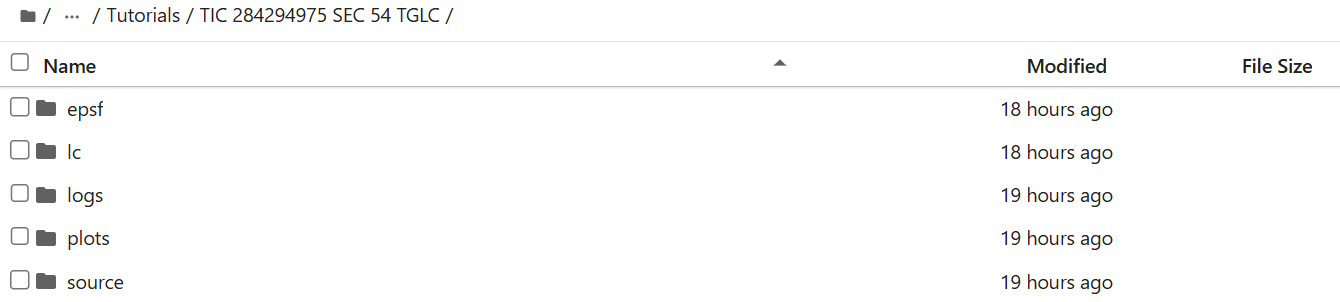

We want the FITS file located within the 'lc' folder as it holds all the data necessary to graph the lightcurve TGLC made for us. Let's open it and see what's inside.

In [6]:
# Opening the FITS file, all of which follow the same naming structure
lc_file = fits.open(f'{target} SEC {sector} TGLC/lc/hlsp_tglc_tess_ffi_gaiaid-2148440330492618624-s0054-cam3-ccd4_tess_v2_llc.fits')

# Checking the information overview of what is contained by the FITS file
lc_file.info()

Filename: TIC 284294975 SEC 54 TGLC/lc/hlsp_tglc_tess_ffi_gaiaid-2148440330492618624-s0054-cam3-ccd4_tess_v2_llc.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      41   (5, 5, 3605)   float32   
  1  LIGHTCURVE    1 BinTableHDU     59   3605R x 9C   [D, E, E, E, E, E, J, I, I]   
  2                1 ImageHDU         8   (5, 5, 3)   float64   


Looks like the data for our lightcurve is located in the first index of our FITS file. Within that index is the PSF flux and time data needed to graph our lightcurve.

But what is PSF flux? In short, the aperture photometry method we used in the previous tutorials is great at efficiently gathering light data from bright, isolated stars as it simply sums up all the light contained in the aperture mask. However, when stars are dimmer, or their pure light data is contaminated by neighboring stars, aperture photometry struggles. To combat this, TGLC uses a technique called Point Spread Function (PSF) photometry, which implements a known theoretical model of how light spreads through a telescope to mathematically isolate a star's light data from that of neighboring stars and the background sky. This is why TGLC is so computationally expensive, but also why it is able to handle such dim and/or crowded stars!

Cool, let's now work with it!

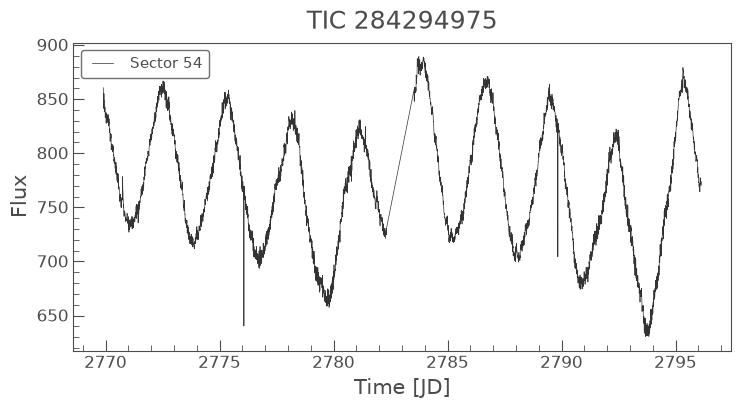

In [7]:
# Gathering and storing the time and PSF flux data from our FITS lightcurve file
time = lc_file[1].data['time']
psf_flux = lc_file[1].data['psf_flux']

# Creating a lightcurve from the data we just gathered
lc = LightCurve(time, psf_flux)

# Plotting the lightcurve we just made
lc.plot(title=target, label=f'Sector {sector}');

## Step 4: Filtering out Bad Data Points
Nice! That looks way better than the sawtooth shape we had before, but we can make it even cleaner. Specifically, we may be able to eliminate those two downspikes (outlier points most likely noise-related) using quality flags. Basically we are creating a boolean mask to check our data and get rid of any points that TESS or TGLC consider "bad". If those two spikes fail the check, then our hypothesis that they are non-astrophysical is justified. If they pass the check, then we know that they are in fact solid data points and maybe something else is going on.

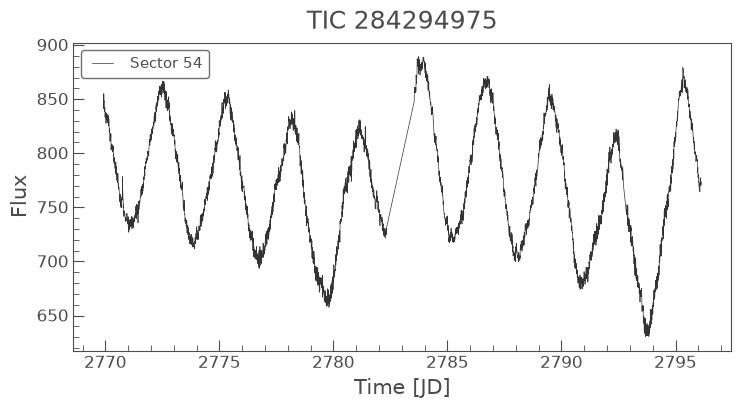

In [13]:
# Create the boolean mask
quality_check_mask = [a and b for a, b in zip(list(lc_file[1].data['TESS_flags'] == 0), list(lc_file[1].data['TGLC_flags'] == 0))]

# Regrab the data, but this time apply that quality check mask to eliminate any "bad" data points
time = lc_file[1].data['time'][quality_check_mask]
psf_flux = lc_file[1].data['psf_flux'][quality_check_mask]

# Recreating and replotting lightcurve
lc = LightCurve(time, psf_flux)
lc.plot(title=target, label=f'Sector {sector}');

# If you wish to save your figure locally:
    # For this example I am saving it to a folder called "Saved Graphs" within my current directory
filename = "TIC 284294975 Sector 54"
plt.savefig(f"Saved Graphs/{filename}")

It looks like the spikes did indeed fail the check, but even if they didn't, it would have been a good idea to use quality flags. Regardless of the outcome, we gain knowledge about our graph that might allow us to make more astute observations about our star.

## Workflow Recap
TGLC is a powerful tool for pulling lightcurves of dim and/or crowded stars, but it's PSF photometry method is very computationally taxing. I suggest first trying the [aperture photometry](https://github.com/aidanniklaus/Summer-Research-2026/blob/main/Tutorials/FFI_LC_Decision_Tree_Tutorial.ipynb) and [quality bitmasking](https://github.com/aidanniklaus/Summer-Research-2026/blob/main/Tutorials/Quality_Bitmasking_LC_Decision_Tree_Tutorial.ipynb) processes we went over in the previous tutorials, then implementing TGLC if necessary. As a reminder, our workflow was as follows:
1. initialize our target, sector, and local directory
2. run TGLC using the initialized info
3. open the FITS lightcurve file TGLC made for us
4. gather and plot the data contained within the FITS lightcurve file
5. visually check graph for possible "bad" datapoints
6. if they exist, create and apply a quality check mask to the data
7. remake and replot lightcurve